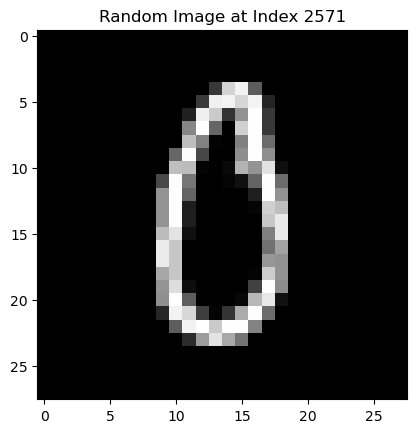

In [45]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label)
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to NumPy array for processing
img = random_image

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()


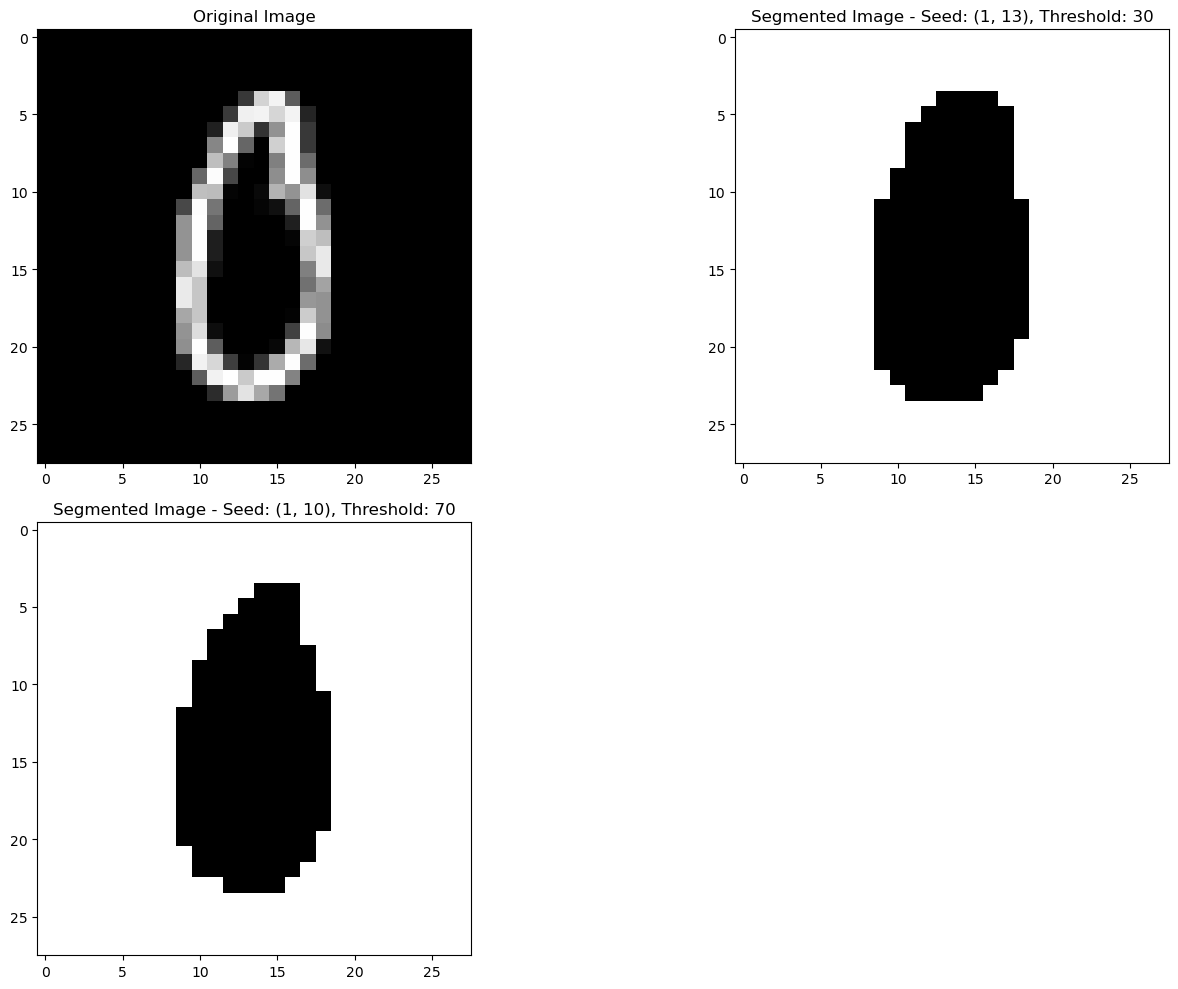

In [46]:
# Get dimensions of the image
rows, cols = img.shape  

# Region Growing Function
def region_growing(img, seed, threshold):
    segmented = np.zeros_like(img)
    seed_x, seed_y = seed
    segmented[seed_x, seed_y] = 255
    region_mean = img[seed_x, seed_y]
    growing = True
    pixels = [(seed_x, seed_y)]
    while growing:
        new_pixels = []
        for x, y in pixels:
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < rows and 0 <= ny < cols and segmented[nx, ny] == 0:
                    if abs(int(img[nx, ny]) - region_mean) < threshold:
                        segmented[nx, ny] = 255
                        new_pixels.append((nx, ny))
        
        if new_pixels:
            region_mean = np.mean([img[x, y] for x, y in new_pixels])
            pixels = new_pixels
        else:
            growing = False
    return segmented

# Define seeds and thresholds
seeds = [(random.randint(0, rows-1), random.randint(0, cols-1)) for _ in range(2)]  # Two random seeds
thresholds = [30, 70]  # Different thresholds

# Plot original image
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

# Process and display segmented images
for i, (seed, threshold) in enumerate(zip(seeds, thresholds)):
    segmented = region_growing(img, seed, threshold)

    plt.subplot(2, 2, i + 2)
    plt.imshow(segmented, cmap='gray')
    plt.title(f'Segmented Image - Seed: {seed}, Threshold: {threshold}')

plt.tight_layout()
plt.show()


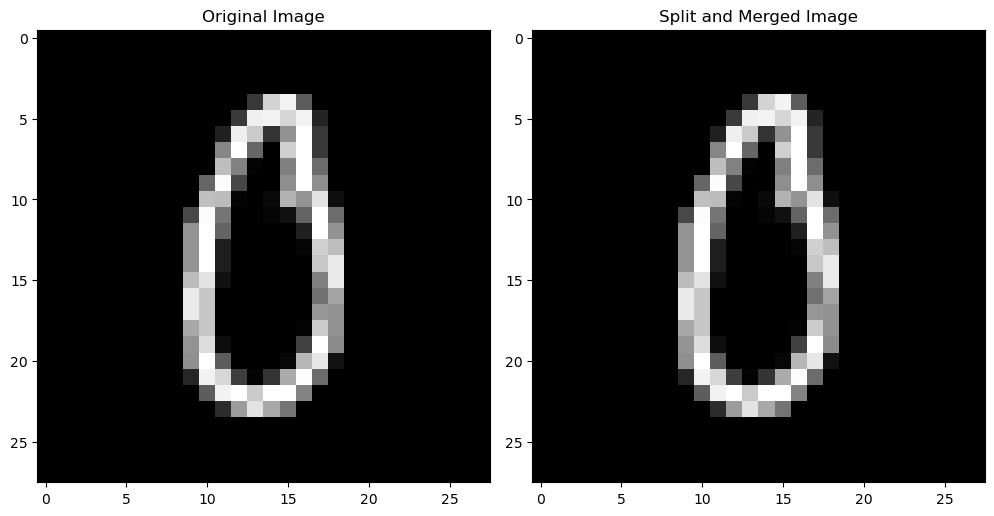

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Function to split and merge the image
def split_and_merge(image, num_regions):
    rows, cols = image.shape
    step = rows // num_regions

    # Split the image into regions
    regions = []
    for i in range(0, rows, step):
        for j in range(0, cols, step):
            # Handle regions that go beyond the image dimensions
            region = image[i:min(i+step, rows), j:min(j+step, cols)]
            regions.append(region)

    # Merge regions based on some similarity criteria
    # You can replace merge_regions with your own merging logic
    regions = merge_regions(regions)

    # Reconstruct the output image from the regions
    output_image = np.zeros_like(image)
    region_idx = 0

    for i in range(0, rows, step):
        for j in range(0, cols, step):
            region_height, region_width = regions[region_idx].shape
            # Ensure the region fits into the output image slice
            output_image[i:i+region_height, j:j+region_width] = regions[region_idx]
            region_idx += 1

    return output_image

# Dummy merge function to simulate the merging of regions
def merge_regions(regions):
    # Example merging logic: just return the regions as-is (no merging)
    return regions

# Split and merge the image
num_regions = 8
split_merged_image = split_and_merge(random_image, num_regions)

# Display the images
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(random_image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(split_merged_image, cmap='gray')
plt.title('Split and Merged Image')

plt.tight_layout()
plt.show()


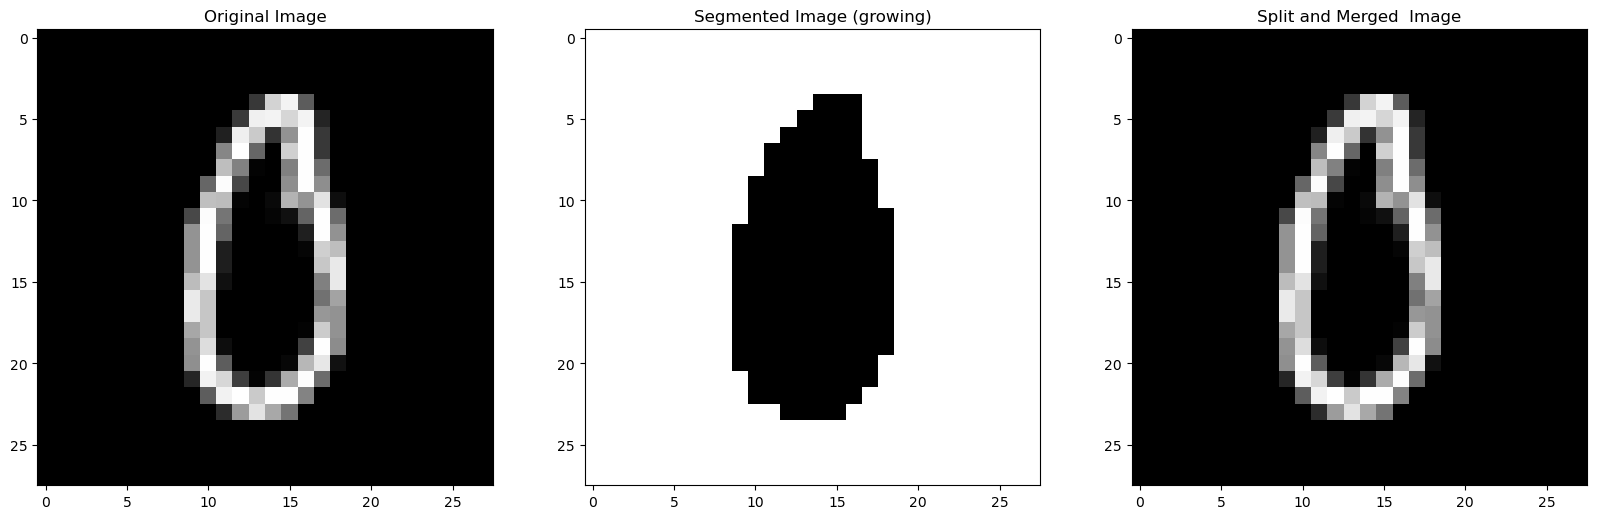

In [48]:
split_merged_image = split_and_merge(img, 4)

plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(segmented, cmap='gray')
plt.title('Segmented Image (growing)')

plt.subplot(1, 3, 3)
plt.imshow(split_merged_image, cmap='gray')
plt.title('Split and Merged  Image')

plt.show()